In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os
import csv
import pandas as pd

import scipy.stats
from sklearn.linear_model import LinearRegression

import torch
from networks_update import Encoder, Decoder
import math
import random

In [3]:
# helper functions
def plot_img(img_arr, slice_idx, title="", cmap="gray"):
    plt.figure(figsize=(2,2))
    plt.imshow(img_arr[slice_idx, :, :], cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()

def plot_img_2d(img_arr, title="", cmap="gray"):
    plt.figure(figsize=(2,2))
    plt.imshow(img_arr, cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()


## Notebook for maping between latents and prelim evaluation of the translation

#### Translating

In [9]:
# Translate all images in folder to their latent encodings

def run_translation():
    folder_to_encode = "./datasets/anat/mouse_train/"
    save_path = "./save_anat_e_d/mouse_train_3/train_latent_encodings/"
    encoder_save_folder = "./save_anat_e_d/mouse_train_3/"
    encoder_epoch = 450


    os.makedirs(save_path, exist_ok=True)

    # Initialize model
    encoder = Encoder(n_downsample=3, n_res=4, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero')

    # load models checkpoint to test
    #print(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))
    encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])

    for file_name in os.listdir(folder_to_encode):
        img = sitk.ReadImage(folder_to_encode + file_name)
        img_arr = sitk.GetArrayFromImage(img)
        img_arr = np.expand_dims(img_arr, axis=0)
        img_torch = torch.from_numpy(img_arr).to(torch.float)

        z = encoder(img_torch.unsqueeze(0))

        torch.save(z, save_path + "encoded_" + file_name + ".pt")

# NOTE: uncomment to run
run_translation()

#### Mapping

In [10]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

class ElementWiseLinear(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))  # scaling factors
        #self.bias = nn.Parameter(torch.zeros(dim))   # biases

    def forward(self, x):
        return x * self.weight # + self.bias


#latent_shape = [16, 32, 30, 30] 
latent_shape = [921600]
latent_len = math.prod(latent_shape)
middle_feat = 2048
do=0.3

MLP = nn.Sequential(
    nn.Linear(latent_len, middle_feat),  # compress
    nn.ReLU(),
    nn.LayerNorm(middle_feat),
    nn.Dropout(do),

    # nn.Linear(middle_feat, middle_feat),    # map in latent space
    # nn.ReLU(),

    nn.Linear(middle_feat, middle_feat),    # map in latent space
    nn.ReLU(),
    
    nn.LayerNorm(middle_feat),
    nn.Dropout(do),

    nn.Linear(middle_feat, latent_len)   # reconstruct
)

class LatentVectorDataset(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder

        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        random.shuffle(self.mouse_encodings_files)
        self.human_encodings_files = os.listdir(human_encodings_folder)
    
    def __len__(self):
        return len(self.mouse_encodings_files)
    
    def __getitem__(self, idx):
        mouse_encoding = torch.from_numpy(np.load(self.mouse_encodings_folder + self.mouse_encodings_files[idx])).float()
        human_encoding = torch.from_numpy(np.load(self.human_encodings_folder + self.human_encodings_files[idx])).float()
        return mouse_encoding, human_encoding
    
    
class LatentVectorAllToAllDataset(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder

        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        
        self.human_encodings_files = os.listdir(human_encodings_folder)

        num_samples = len(self.mouse_encodings_files)
        self.mouse_idxs = np.ones(num_samples**2, dtype=int)

        # To pair every idx with every idx...
        for i in range(num_samples):
            # set mouse_idxs to be [0, 0, ..., 1, 1, ..., ......, num_samples-1, num_samples-1, ...]
            self.mouse_idxs[i*num_samples : (i+1)*num_samples] = i

        # set human_idxs to be [0, 1, ..., num_samples-1, ........, 0, 1, ..., num_samples-1]
        self.human_idxs = np.arange(num_samples**2) % num_samples

        # Shuffle the pairs to get the train dataset

        perm = np.random.permutation(num_samples**2)
        self.human_idxs = self.human_idxs[perm]
        self.mouse_idxs = self.mouse_idxs[perm]
    
    def __len__(self):
        return len(self.mouse_idxs)
    
    def __getitem__(self, idx):
        mouse_encoding = torch.load(self.mouse_encodings_folder + self.mouse_encodings_files[self.mouse_idxs[idx]]).flatten().detach()
        human_encoding = torch.load(self.human_encodings_folder + self.human_encodings_files[self.human_idxs[idx]]).flatten().detach()
        return mouse_encoding, human_encoding
    
    

class LatentVectorsPairByGM(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder, k=0, sort=True):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder
        
        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        self.human_encodings_files = os.listdir(human_encodings_folder)

        num_samples = min(len(self.mouse_encodings_files), len(self.human_encodings_files))
        self.mouse_encodings_files = self.mouse_encodings_files[:num_samples]
        self.human_encodings_files = self.human_encodings_files[:num_samples]

        self.paths = ([mouse_encodings_folder + file for file in self.mouse_encodings_files]) + ([human_encodings_folder + file for file in self.human_encodings_files])
        #random.seed(0)
        #random.shuffle(self.paths) # shuffle to mix up mice and human paths

        # compute wm/gm/csf ratios
        self.features = []
        self.species = []
        for path in self.paths:
            split_path = path.split("/")
            is_mouse = False
            is_test = False

            if split_path[4].split("_")[0] == "mouse":
                self.species.append(0)
                is_mouse = True
            else:
                self.species.append(1)

            is_test = (split_path[4].split("_")[1] == "test")

            img_path = "./datasets/3d_larger/" + ("mouse_" if is_mouse else "human_") + ("test/" if is_test else "train/") + split_path[-1][0:-3] +"nii"
            img_arr = sitk.GetArrayFromImage(sitk.ReadImage(img_path))

            gm_count = np.sum(img_arr == 1)
            wm_count = np.sum(img_arr == 2)
            csf_count = np.sum(img_arr == 3)
            total_count = gm_count + wm_count + csf_count

            ratios = []
            ratios.append(gm_count/total_count)
            ratios.append(wm_count/total_count)
            ratios.append(csf_count/total_count)

            self.features.append(ratios)
        
        self.mouse_features = np.array(self.features[:num_samples])
        self.human_features = np.array(self.features[num_samples:])
        
        # calc mean and std to z-norm for loss term
        self.mouse_features_mean = np.mean(self.mouse_features, axis=0)
        self.mouse_features_std = np.std(self.mouse_features, axis=0)

        self.mouse_features = (self.mouse_features - self.mouse_features_mean) / self.mouse_features_std

        # calc mean and std to z-norm for loss term
        self.human_features_mean = np.mean(self.human_features, axis=0)
        self.human_features_std = np.std(self.human_features, axis=0)

        self.human_features_non_norm = self.human_features

        self.human_features = (self.human_features - self.human_features_mean) / self.human_features_std


        # from path, features, species arrays - split by species and reorder by gm low to high
        self.mouse_encodings_paths = np.array(self.paths[:num_samples])
        self.human_encodings_paths = np.array(self.paths[num_samples:])

        if sort:
            print("SORTED")
            mouse_sort_order = torch.argsort(self.features[:num_samples, 0])
            human_sort_order = torch.argsort(self.features[num_samples:, 0])

            self.gm_mouse = self.features[:num_samples, 0][mouse_sort_order]
            self.gm_human = self.features[num_samples:, 0][human_sort_order]


            self.mouse_encodings_paths_sorted = self.mouse_encodings_paths[mouse_sort_order]
            self.human_encodings_paths_sorted = self.human_encodings_paths[human_sort_order]

            if k != 0:
                # pair with neighbourhood of up to 1 + 2k
                self.gm_mouse_dup = []
                self.gm_human_dup = []

                for i in range(len(self.gm_mouse)):
                    start = max(0, i - k)
                    end = min(len(self.gm_mouse), i + k + 1)

                    neighbors = self.gm_human[start:end]
                    self.gm_mouse_dup.extend([self.gm_mouse[i]] * len(neighbors))
                    self.gm_human_dup.extend(neighbors)
                
                self.gm_mouse = np.array(self.gm_mouse_dup)
                self.gm_human = np.array(self.gm_human_dup)

            shuffle = torch.randperm(num_samples)
            self.gm_mouse = self.gm_mouse[shuffle]
            self.gm_human = self.gm_human[shuffle]
            
        else:
            self.mouse_encodings_paths_sorted = self.mouse_encodings_paths
            self.human_encodings_paths_sorted = self.human_encodings_paths

    def get_human_features_min_maxes(self):
        return np.min(self.human_features_non_norm, axis=0), np.max(self.human_features_non_norm, axis=0)


    def get_human_features_non_norm(self, num):
        return self.human_features_non_norm[:, :num]

    def get_mouse_mean_and_std(self):
        return self.mouse_features_mean, self.mouse_features_std
    
    def get_human_mean_and_std(self):
        return self.human_features_mean, self.human_features_std

    def get_features(self):
        return self.human_features, self.mouse_features
    
    def __getitem__(self, idx):
        mouse_latent_encoding = torch.from_numpy(np.load(self.mouse_encodings_paths_sorted[idx], allow_pickle=True)).float()#.detach().flatten()
        human_latent_encoding = torch.from_numpy(np.load(self.human_encodings_paths_sorted[idx], allow_pickle=True)).float()#.detach().flatten()

        #return [mouse_latent_encoding, human_latent_encoding]
        return [mouse_latent_encoding, human_latent_encoding, self.mouse_features[idx]]
    
    def __len__(self):
        return len(self.human_encodings_paths_sorted)
    
    def plot_gm_pairing(self):
        plt.figure()
        plt.plot(self.gm_mouse, label="mouse")
        plt.plot(self.gm_human, label="human")
        plt.legend()
        plt.title("Sorted GM ratios")
        plt.show()

        plt.figure()
        plt.plot(self.gm_mouse, self.gm_human)
        plt.title("Paired GM ratios")
        plt.show()

    def plot_gm_multi_pairing(self):
        plt.figure()
        plt.scatter(self.gm_mouse_dup, self.gm_human_dup, color="magenta", s=1)
        plt.title("Multi paired GM ratios")
        plt.show()


    

In [ ]:
class LatentVectorsVolRatios(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder, k=0, sort=True):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder
        
        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        self.human_encodings_files = os.listdir(human_encodings_folder)

        num_samples = min(len(self.mouse_encodings_files), len(self.human_encodings_files))
        self.mouse_encodings_files = self.mouse_encodings_files[:num_samples]
        self.human_encodings_files = self.human_encodings_files[:num_samples]

        self.paths = ([mouse_encodings_folder + file for file in self.mouse_encodings_files]) + ([human_encodings_folder + file for file in self.human_encodings_files])
        #random.seed(0)
        #random.shuffle(self.paths) # shuffle to mix up mice and human paths

        # compute vol ratios
        self.features = []
        self.species = []
        for path in self.paths:
            split_path = path.split("/")
            is_mouse = False
            is_test = False

            if split_path[4].split("_")[0] == "mouse":
                self.species.append(0)
                is_mouse = True
            else:
                self.species.append(1)

            is_test = (split_path[4].split("_")[1] == "test")

            img_path = "./datasets/3d_larger/" + ("mouse_" if is_mouse else "human_") + ("test/" if is_test else "train/") + split_path[-1][0:-3] +"nii"
            img_arr = sitk.GetArrayFromImage(sitk.ReadImage(img_path))

            gm_count = np.sum(img_arr == 1)
            wm_count = np.sum(img_arr == 2)
            csf_count = np.sum(img_arr == 3)
            total_count = gm_count + wm_count + csf_count

            ratios = []
            ratios.append(gm_count/total_count)
            ratios.append(wm_count/total_count)
            ratios.append(csf_count/total_count)

            self.features.append(ratios)
        
        self.mouse_features = np.array(self.features[:num_samples])
        self.human_features = np.array(self.features[num_samples:])
        
        # calc mean and std to z-norm for loss term
        self.mouse_features_mean = np.mean(self.mouse_features, axis=0)
        self.mouse_features_std = np.std(self.mouse_features, axis=0)

        self.mouse_features = (self.mouse_features - self.mouse_features_mean) / self.mouse_features_std

        # calc mean and std to z-norm for loss term
        self.human_features_mean = np.mean(self.human_features, axis=0)
        self.human_features_std = np.std(self.human_features, axis=0)

        self.human_features_non_norm = self.human_features

        self.human_features = (self.human_features - self.human_features_mean) / self.human_features_std


        # from path, features, species arrays - split by species and reorder by gm low to high
        self.mouse_encodings_paths = np.array(self.paths[:num_samples])
        self.human_encodings_paths = np.array(self.paths[num_samples:])

        if sort:
            print("SORTED")
            mouse_sort_order = torch.argsort(self.features[:num_samples, 0])
            human_sort_order = torch.argsort(self.features[num_samples:, 0])

            self.gm_mouse = self.features[:num_samples, 0][mouse_sort_order]
            self.gm_human = self.features[num_samples:, 0][human_sort_order]


            self.mouse_encodings_paths_sorted = self.mouse_encodings_paths[mouse_sort_order]
            self.human_encodings_paths_sorted = self.human_encodings_paths[human_sort_order]

            if k != 0:
                # pair with neighbourhood of up to 1 + 2k
                self.gm_mouse_dup = []
                self.gm_human_dup = []

                for i in range(len(self.gm_mouse)):
                    start = max(0, i - k)
                    end = min(len(self.gm_mouse), i + k + 1)

                    neighbors = self.gm_human[start:end]
                    self.gm_mouse_dup.extend([self.gm_mouse[i]] * len(neighbors))
                    self.gm_human_dup.extend(neighbors)
                
                self.gm_mouse = np.array(self.gm_mouse_dup)
                self.gm_human = np.array(self.gm_human_dup)

            shuffle = torch.randperm(num_samples)
            self.gm_mouse = self.gm_mouse[shuffle]
            self.gm_human = self.gm_human[shuffle]
            
        else:
            self.mouse_encodings_paths_sorted = self.mouse_encodings_paths
            self.human_encodings_paths_sorted = self.human_encodings_paths

    def get_human_features_min_maxes(self):
        return np.min(self.human_features_non_norm, axis=0), np.max(self.human_features_non_norm, axis=0)


    def get_human_features_non_norm(self, num):
        return self.human_features_non_norm[:, :num]

    def get_mouse_mean_and_std(self):
        return self.mouse_features_mean, self.mouse_features_std
    
    def get_human_mean_and_std(self):
        return self.human_features_mean, self.human_features_std

    def get_features(self):
        return self.human_features, self.mouse_features
    
    def __getitem__(self, idx):
        mouse_latent_encoding = torch.from_numpy(np.load(self.mouse_encodings_paths_sorted[idx], allow_pickle=True)).float()#.detach().flatten()
        human_latent_encoding = torch.from_numpy(np.load(self.human_encodings_paths_sorted[idx], allow_pickle=True)).float()#.detach().flatten()

        #return [mouse_latent_encoding, human_latent_encoding]
        return [mouse_latent_encoding, human_latent_encoding, self.mouse_features[idx]]
    
    def __len__(self):
        return len(self.human_encodings_paths_sorted)
    
    def plot_gm_pairing(self):
        plt.figure()
        plt.plot(self.gm_mouse, label="mouse")
        plt.plot(self.gm_human, label="human")
        plt.legend()
        plt.title("Sorted GM ratios")
        plt.show()

        plt.figure()
        plt.plot(self.gm_mouse, self.gm_human)
        plt.title("Paired GM ratios")
        plt.show()

    def plot_gm_multi_pairing(self):
        plt.figure()
        plt.scatter(self.gm_mouse_dup, self.gm_human_dup, color="magenta", s=1)
        plt.title("Multi paired GM ratios")
        plt.show()

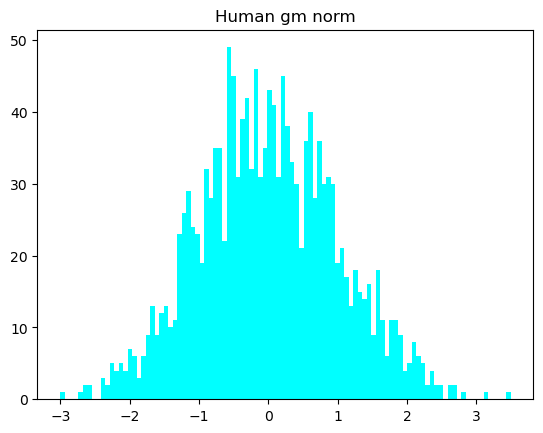

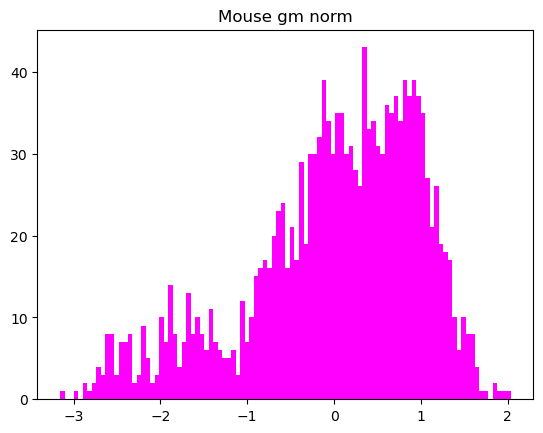

In [5]:
# mouse_encodings_folder = "./pca/pca_mouse_train_100_encode/"
# human_encodings_folder = "./pca/pca_human_train_100_encode/"

mouse_encodings_folder = "./pca/3d_larger/final/mouse_train_encode/"
human_encodings_folder = "./pca/3d_larger/final/human_train_encode/"

dataset = LatentVectorsPairByGM(mouse_encodings_folder, human_encodings_folder, k=0, sort=False)
human_features, mouse_features = dataset.get_features()
human_features_means, human_features_stds = dataset.get_human_mean_and_std()
human_features_mins, human_features_maxs = dataset.get_human_features_min_maxes()
num = 1000 # get 1000 random samples
real_human_features = dataset.get_human_features_non_norm(num)
real_human_gm = real_human_features[:, 0]
real_human_wm = real_human_features[:, 1]
real_human_csf = real_human_features[:, 2]

bins = 100
plt.figure()
plt.hist(human_features[:, 0], bins=bins, color="cyan")
plt.title("Human gm norm")
plt.show()

plt.figure()
plt.hist(mouse_features[:, 0], bins=bins, color="magenta")
plt.title("Mouse gm norm")
plt.show()


In [6]:
def plot_img(img):
    print("pca")
    plt.figure(figsize=(2,3))
    plt.imshow(img[0].detach().cpu().numpy().reshape(120, 120), cmap="gray")
    plt.show()

    print("non diff convert")
    print(get_gm_non_diff(img))
    img_non_diff = torch.round(torch.clamp(img, 0, 3))
    plt.figure(figsize=(2,3))
    plt.imshow(img_non_diff[0].detach().cpu().numpy().reshape(120, 120), cmap="gray")
    plt.colorbar()
    plt.show()

    print("diff convert")
    print(get_gm_diff(img))
    min_approx=-0.25
    max_approx=3.35

    img_diff = 3*((img - min_approx) / (max_approx - min_approx))
    plt.figure(figsize=(2,3))
    plt.imshow(img_diff[0].detach().cpu().numpy().reshape(120, 120), cmap="gray")
    plt.colorbar()
    plt.show()


    sigma = 0.3
    prob_gm = torch.exp(-(img_diff - 1)**2 / (2 * sigma**2))
    plt.figure(figsize=(2,3))
    plt.imshow(prob_gm[0].detach().cpu().numpy().reshape(120, 120), cmap="gray")
    plt.colorbar()
    plt.show()

def get_gm_non_diff(img): # ***** FIX

    img = torch.round(torch.clamp(img, 0, 3))
    img = img.view(-1, 120*120*128)
    

    gm_count = torch.sum(img == 1, dim=(1)).float()
    wm_count = torch.sum(img == 2, dim=(1)).float()
    csf_count = torch.sum(img == 3, dim=(1)).float()
    tot_count = gm_count + wm_count + csf_count + 1e-6  # prevent division by zero

    gm_ratio = gm_count / tot_count


    return gm_ratio

def get_gm_diff(img, min_approx=-0.5, max_approx=3.35):
    sigma = 0.35
    img = 3*((img - min_approx) / (max_approx - min_approx))
    img = img.view(-1, 120*120*128)

    soft_mask_1 = torch.exp(-(img - 1)**2 / (2 * sigma**2))
    soft_mask_2 = torch.exp(-(img - 2)**2 / (2 * sigma**2))
    soft_mask_3 = torch.exp(-(img - 3)**2 / (2 * sigma**2))

    gm_count = soft_mask_1.sum(dim=1)
    wm_count = soft_mask_2.sum(dim=1)
    csf_count = soft_mask_3.sum(dim=1)
    tot_count = gm_count + wm_count + csf_count + 1e-6

    gm_ratio = gm_count / tot_count

    return gm_ratio

def get_matter_ratios_diff(img, min_approx=-0.5, max_approx=3.35):
    sigma = 0.35
    img = 3*((img - min_approx) / (max_approx - min_approx))
    img = img.view(-1, 120*120*128)

    soft_mask_1 = torch.exp(-(img - 1)**2 / (2 * sigma**2))
    soft_mask_2 = torch.exp(-(img - 2)**2 / (2 * sigma**2))
    soft_mask_3 = torch.exp(-(img - 3)**2 / (2 * sigma**2))

    gm_count = soft_mask_1.sum(dim=1)
    wm_count = soft_mask_2.sum(dim=1)
    csf_count = soft_mask_3.sum(dim=1)
    tot_count = gm_count + wm_count + csf_count + 1e-6

    gm_ratio = gm_count / tot_count
    wm_ratio = wm_count / tot_count
    csf_ratio = csf_count / tot_count

    return gm_ratio, wm_ratio, csf_ratio


In [ ]:
# Test out different models to learn the mapping between latent vectors
import csv
import pickle

# with open("./pca/2d_pca_100_human.pkl", 'rb') as f:
#     pca_human = pickle.load(f)

# with open("./pca/2d_scaler_100_human.pkl", 'rb') as f:
#     scaler_human = pickle.load(f)

    # load pca and scaler
with open('./pca/3d_larger/final/pca_mouse.pkl', 'rb') as f:
    pca_mouse = pickle.load(f)

with open('./pca/3d_larger/final/scaler_mouse.pkl', 'rb') as f:
    scaler_mouse = pickle.load(f)

with open('./pca/3d_larger/final/pca_human.pkl', 'rb') as f:
    pca_human = pickle.load(f)

with open('./pca/3d_larger/final/scaler_human.pkl', 'rb') as f:
    scaler_human = pickle.load(f)

# convert to torch ops
pca_components = torch.tensor(pca_human.components_, device="cuda", dtype=torch.float32)
pca_mean = torch.tensor(pca_human.mean_, device="cuda", dtype=torch.float32)

scaler_mean = torch.tensor(scaler_human.mean_, device="cuda", dtype=torch.float32)
scaler_scale = torch.tensor(scaler_human.scale_, device="cuda", dtype=torch.float32)


# load data into random ordered vectors
# mouse_encodings_folder = "./save_2d/2d_larger/mouse_train_1/train_latent_encodings/"
# human_encodings_folder = "./save_2d/2d_larger/human_train_1/train_latent_encodings/"

# mouse_test_encodings_folder = "./save_2d/2d_larger/mouse_train_1/test_latent_encodings/"
# human_test_encodings_folder = "./save_2d/2d_larger/human_train_1/test_latent_encodings/"

# mouse_encodings_folder = "./pca/3d_larger/final/mouse_train_encode/"
# human_encodings_folder = "./pca/3d_larger/final/human_train_encode/"

# mouse_test_encodings_folder = "./pca/3d_larger/final/mouse_test_encode/"
# human_test_encodings_folder = "./pca/3d_larger/final/human_test_encode/"

mouse_encodings_folder = "./pca/3d_larger/final/mouse_train_encode/"
human_encodings_folder = "./pca/3d_larger/final/human_train_encode/"

mouse_test_encodings_folder = "./pca/3d_larger/final/mouse_test_encode/"
human_test_encodings_folder = "./pca/3d_larger/final/human_test_encode/"


dataset = LatentVectorsPairByGM(mouse_encodings_folder, human_encodings_folder, k=0, sort=False)
human_ratios_means, human_ratios_stds = dataset.get_human_mean_and_std()

batch_size = 124
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

valdataset = LatentVectorsPairByGM(mouse_test_encodings_folder, human_test_encodings_folder, k=0, sort=False)
valloader = DataLoader(valdataset, batch_size=batch_size, shuffle=True, num_workers=4)

model = MLP.cuda() #ElementWiseLinear(latent_len).cuda()  # move to GPU
#model.load_state_dict(torch.load('./pca/gm_loss_mod_500.pth')['model_state_dict'])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
#optimizer.load_state_dict(torch.load('./pca/gm_loss_mod_500.pth')['optimizer_state_dict'])

csv_path = "./pca/3d_larger/final/matter_loss/test_3d.csv"
mode = 'w' # 'w' -> overwrite, 'a' -> append


if mode == 'w': # new file
    with open(csv_path, mode=mode, newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "loss", "val_loss", "train_mse_loss", "val_mse_loss", "train_gm_loss", "val_gm_loss", "train_wm_loss", "val_wm_loss", "train_csf_loss", "val_csf_loss", "train_loss_gm_non_diff", "val_loss_gm_non_diff"])

def latent_variance_loss(z):
    # z: [batch_size, latent_dim]
    var = torch.var(z, dim=0)  # variance across batch
    return -torch.mean(var)  # maximize variance


# Training loop
start_epoch = 0
epochs = 200
save_loss = []
epsilon = 1e-6
alpha = 0.1
beta = 0.01
pca_encodings = []

print("start training!!")
for epoch in range(start_epoch, epochs + start_epoch):
    model.train()

    train_loss = 0.0
    train_loss_gm_non_diff = 0.0
    train_gm_loss = 0.0
    train_wm_loss = 0.0
    train_csf_loss = 0.0
    train_mse_loss = 0.0
    for mouse_batch, human_batch, mouse_features_batch in dataloader:
        # normalize batches
        # mouse_batch = (mouse_batch - mouse_means) / (mouse_stds + epsilon) 
        # human_batch = (human_batch - human_means) / (human_stds + epsilon) 

        mouse_batch = mouse_batch.cuda()
        human_batch = human_batch.cuda()
        mouse_features_batch = mouse_features_batch.cuda()

        optimizer.zero_grad()
        human_pca_encoding = model(mouse_batch)

        # Inverse PCA (linear reconstruction)
        human_trans = torch.matmul(human_pca_encoding, pca_components) + pca_mean

        # Inverse standard scaling
        human_trans_unscaled = human_trans * scaler_scale + scaler_mean

        gm_ratio_non_diff = get_gm_non_diff(human_trans_unscaled)
        gm_ratio_diff, wm_ratio_diff, csf_ratio_diff = get_matter_ratios_diff(human_trans_unscaled)

        gm_ratio_norm_non_diff = (gm_ratio_non_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
        gm_ratio_norm_diff = (gm_ratio_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
        wm_ratio_norm_diff = (wm_ratio_diff - human_ratios_means[1]) / (human_ratios_stds[1] + 1e-6)
        csf_ratio_norm_diff = (csf_ratio_diff - human_ratios_means[2]) / (human_ratios_stds[2] + 1e-6)

        mse_loss = criterion(human_pca_encoding, mouse_batch) # NOTE: biggggg error

        gm_loss = torch.mean(torch.abs(mouse_features_batch[:, 0] - gm_ratio_norm_diff))
        wm_loss = torch.mean(torch.abs(mouse_features_batch[:, 1] - wm_ratio_norm_diff))
        csf_loss = torch.mean(torch.abs(mouse_features_batch[:, 2] - csf_ratio_norm_diff))

        gm_loss_non_diff = torch.mean(torch.abs(mouse_features_batch[:, 0] - gm_ratio_norm_non_diff)) # non diff
        loss = beta*mse_loss + alpha*(gm_loss + wm_loss + csf_loss)

        loss.backward()
        optimizer.step()

        train_mse_loss += mse_loss.item() * mouse_batch.size(0)
        train_gm_loss += gm_loss.item() * mouse_batch.size(0)
        train_wm_loss += wm_loss.item() * mouse_batch.size(0)
        train_csf_loss += csf_loss.item() * mouse_batch.size(0)
        train_loss_gm_non_diff += gm_loss_non_diff.item() * mouse_batch.size(0)
        train_loss += loss.item() * mouse_batch.size(0)
        

    train_mse_loss = train_mse_loss / len(dataset)
    train_gm_loss = train_gm_loss / len(dataset)
    train_wm_loss = train_wm_loss / len(dataset)
    train_csf_loss = train_csf_loss / len(dataset)
    train_loss_gm_non_diff = train_loss_gm_non_diff / len(dataset)
    train_loss = train_loss / len(dataset)

    model.eval()
    val_loss = 0.0
    val_loss_gm_non_diff = 0.0
    val_gm_loss = 0.0
    val_wm_loss = 0.0
    val_csf_loss = 0.0
    val_mse_loss = 0.0


    #plot_img(human_trans_unscaled)
    
    for mouse_batch, human_batch, mouse_features_batch in valloader:
        # normalize batches
        # mouse_batch = (mouse_batch - mouse_means) / (mouse_stds + epsilon) 
        # human_batch = (human_batch - human_means) / (human_stds + epsilon) 

        mouse_batch = mouse_batch.cuda()
        human_batch = human_batch.cuda()

        mouse_features_batch = mouse_features_batch.cuda()

        optimizer.zero_grad()
        human_pca_encoding = model(mouse_batch)

        # Inverse PCA (linear reconstruction)
        human_trans = torch.matmul(human_pca_encoding, pca_components) + pca_mean

        # Inverse standard scaling
        human_trans_unscaled = human_trans * scaler_scale + scaler_mean

        gm_ratio_non_diff = get_gm_non_diff(human_trans_unscaled)
        gm_ratio_diff, wm_ratio_diff, csf_ratio_diff = get_matter_ratios_diff(human_trans_unscaled)

        gm_ratio_norm_non_diff = (gm_ratio_non_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
        gm_ratio_norm_diff = (gm_ratio_diff - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)
        wm_ratio_norm_diff = (wm_ratio_diff - human_ratios_means[1]) / (human_ratios_stds[1] + 1e-6)
        csf_ratio_norm_diff = (csf_ratio_diff - human_ratios_means[2]) / (human_ratios_stds[2] + 1e-6)

        mse_loss = criterion(human_pca_encoding, mouse_batch) 

        gm_loss = torch.mean(torch.abs(mouse_features_batch[:, 0] - gm_ratio_norm_diff))
        wm_loss = torch.mean(torch.abs(mouse_features_batch[:, 1] - wm_ratio_norm_diff))
        csf_loss = torch.mean(torch.abs(mouse_features_batch[:, 2] - csf_ratio_norm_diff))

        gm_loss_non_diff = torch.mean(torch.abs(mouse_features_batch[:, 0] - gm_ratio_norm_non_diff)) # non diff
        loss = beta*mse_loss + alpha*(gm_loss + wm_loss + csf_loss)
        
        val_mse_loss += mse_loss.item() * mouse_batch.size(0)
        val_gm_loss += gm_loss.item() * mouse_batch.size(0)
        val_wm_loss += wm_loss.item() * mouse_batch.size(0)
        val_csf_loss += csf_loss.item() * mouse_batch.size(0)
        val_loss_gm_non_diff += gm_loss_non_diff.item() * mouse_batch.size(0)
        val_loss += loss.item() * mouse_batch.size(0)


    val_gm_loss = val_gm_loss / len(valdataset)
    val_wm_loss = val_wm_loss / len(valdataset)
    val_csf_loss = val_csf_loss / len(valdataset)
    val_mse_loss = val_mse_loss / len(valdataset)
    val_loss_gm_non_diff = val_loss_gm_non_diff / len(valdataset)
    val_loss = val_loss / len(valdataset)
    #plot_img(human_trans_unscaled)

    print(f"Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    with open(csv_path, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch, train_loss, val_loss, train_mse_loss, val_mse_loss, train_gm_loss, val_gm_loss, train_wm_loss, val_wm_loss, train_csf_loss, val_csf_loss, train_loss_gm_non_diff, val_loss_gm_non_diff])


# 1000 takes ~ 7 min


start training!!
Epoch 1, Train Loss: 13.239128, Val Loss: 9.110330
Epoch 2, Train Loss: 13.087677, Val Loss: 8.978168
Epoch 3, Train Loss: 12.967929, Val Loss: 8.850055
Epoch 4, Train Loss: 12.850301, Val Loss: 8.723797
Epoch 5, Train Loss: 12.733650, Val Loss: 8.607466
Epoch 6, Train Loss: 12.623836, Val Loss: 8.504522
Epoch 7, Train Loss: 12.523914, Val Loss: 8.415630
Epoch 8, Train Loss: 12.436070, Val Loss: 8.337381
Epoch 9, Train Loss: 12.357621, Val Loss: 8.267921
Epoch 10, Train Loss: 12.288519, Val Loss: 8.206489
Epoch 11, Train Loss: 12.225876, Val Loss: 8.150101
Epoch 12, Train Loss: 12.168789, Val Loss: 8.098720
Epoch 13, Train Loss: 12.115352, Val Loss: 8.051246
Epoch 14, Train Loss: 12.065396, Val Loss: 8.006826
Epoch 15, Train Loss: 12.018041, Val Loss: 7.965116
Epoch 16, Train Loss: 11.975347, Val Loss: 7.926454
Epoch 17, Train Loss: 11.933881, Val Loss: 7.889453
Epoch 18, Train Loss: 11.893763, Val Loss: 7.854307
Epoch 19, Train Loss: 11.853900, Val Loss: 7.820183
Epoc

In [8]:
err

NameError: name 'err' is not defined

In [ ]:
# save the mapping model
#errr
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch
}, './pca/all_matters_a_3_mod.pth')


199


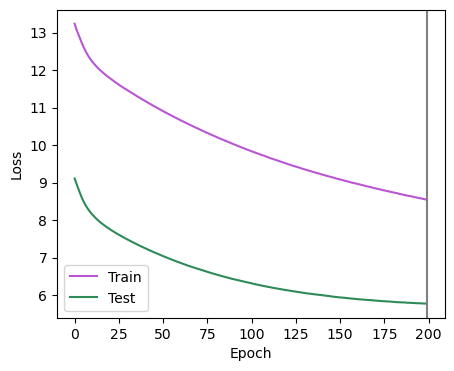

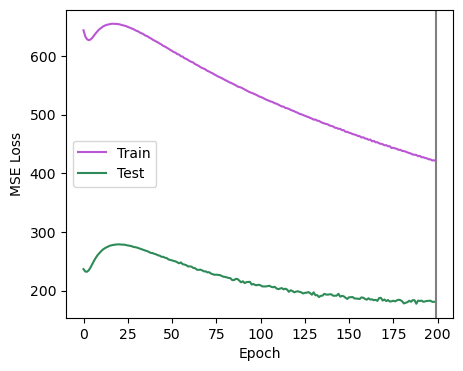

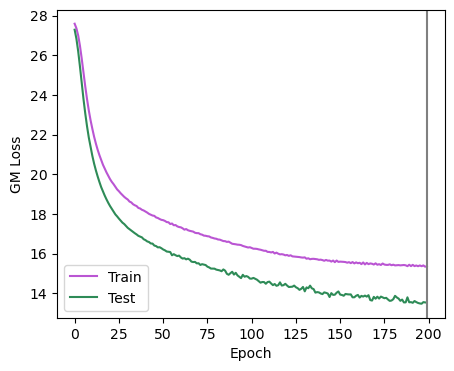

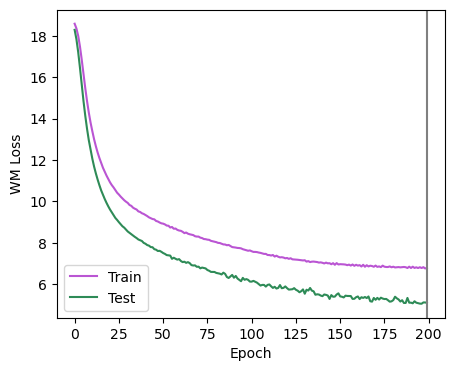

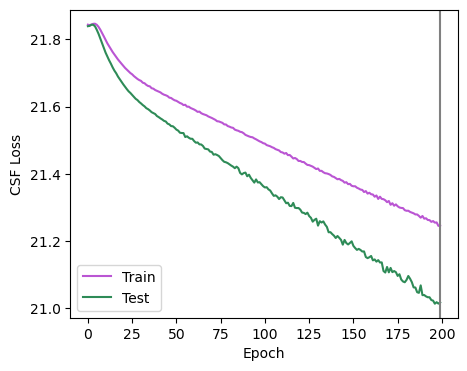

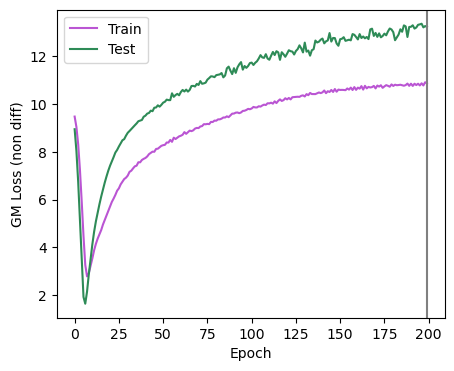

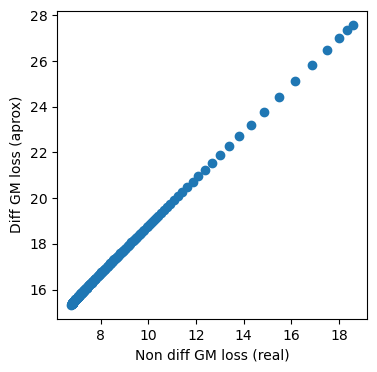

In [9]:
# 1. Plot loss
loss = pd.read_csv("./pca/3d_larger/final/matter_loss/test_3d.csv")
#test_loss = pd.read_csv("./save_models/human_train_1/test_loss_log.csv")

min_test = loss.iloc[:, 0][np.argmin(loss.iloc[:, 2])]
print(min_test)

plt.figure(figsize=(5,4))
plt.plot(loss.iloc[:, 1], color="mediumorchid")
plt.plot(loss.iloc[:, 2], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.show()

plt.figure(figsize=(5,4))
plt.plot(loss.iloc[:, 3], color="mediumorchid")
plt.plot(loss.iloc[:, 4], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.show()

plt.figure(figsize=(5,4))
plt.plot(loss.iloc[:, 5], color="mediumorchid")
plt.plot(loss.iloc[:, 6], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("GM Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.show()

plt.figure(figsize=(5,4))
plt.plot(loss.iloc[:, 7], color="mediumorchid")
plt.plot(loss.iloc[:, 8], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("WM Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.show()

plt.figure(figsize=(5,4))
plt.plot(loss.iloc[:, 9], color="mediumorchid")
plt.plot(loss.iloc[:, 10], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("CSF Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.show()

plt.figure(figsize=(5,4))
plt.plot(loss.iloc[:, 11], color="mediumorchid")
plt.plot(loss.iloc[:, 12], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("GM Loss (non diff)")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.show()

# plot non diff loss from diff loss
plt.figure(figsize=(4,4))
plt.scatter(loss.iloc[:, 7], loss.iloc[:, 5])
plt.xlabel("Non diff GM loss (real)")
plt.ylabel("Diff GM loss (aprox)")
plt.show()

In [ ]:
# Now test the translating model!!!
# (for a sample decode to reconstructed and transaated - with model trained above)

# 2D
import pickle
# load pca and scaler
with open("./pca/2d_pca_100_mouse.pkl", 'rb') as f:
    pca_mouse = pickle.load(f)

with open("./pca/2d_scaler_100_mouse.pkl", 'rb') as f:
    scaler_mouse = pickle.load(f)

with open("./pca/2d_pca_100_human.pkl", 'rb') as f:
    pca_human = pickle.load(f)

with open("./pca/2d_scaler_100_human.pkl", 'rb') as f:
    scaler_human = pickle.load(f)
    

# folder with model checkpoints
encoder_save_folder = "./save_2d/2d_larger/mouse_train_1/"
decoder_save_folder = "./save_2d/2d_larger/human_train_1/"

# checkpoint to load
encoder_epoch = 1000
decoder_epoch = 1000

# Encode with mouse encoder and decode with human decoder
test_folder = "./datasets/2d_larger/mouse_test/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
test_paths.sort()

idxs = np.arange(len(test_paths))

# folder to save translated images to
save_path = "./save_2d/2d_larger/train_1_MLP/k_2_test_new/"
os.makedirs(save_path, exist_ok=True)

# Initialize model
encoder = Encoder(n_downsample=3, n_res=2, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero')
decoder_recon = Decoder(n_upsample=3, n_res=2, dim=encoder.output_dim, output_dim=4)
decoder_trans = Decoder(n_upsample=3, n_res=2, dim=encoder.output_dim, output_dim=4)

# load models checkpoint to test
encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])
decoder_recon.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['decoder_state_dict'])
decoder_trans.load_state_dict(torch.load(decoder_save_folder + "checkpoint_epoch_" + str(decoder_epoch))['decoder_state_dict'])

# load the mapping model too OR reuse from above
#model = MLP.cuda() 
#model.load_state_dict(torch.load('./save_2d/mapping_models/train_3_MLP_pair_one.pth')['model_state_dict'])

encoder.eval()
decoder_recon.eval()
decoder_trans.eval()
model.eval()

for idx in idxs:
    img = sitk.ReadImage(test_paths[idx])
    img_arr = sitk.GetArrayFromImage(img)
    img_arr = np.expand_dims(img_arr, axis=0)
    img_torch = torch.from_numpy(img_arr).to(torch.float)

    z = encoder(img_torch.unsqueeze(0))

    # the translating model trained above
    z_trans = model(z.flatten().cuda()).cpu()#*human_stds + human_means

    # de-normalize before reshaping
    z_trans = z_trans.reshape(z.shape)

    recon_img = decoder_recon(z)
    recon_img = torch.argmax(recon_img, dim=1)
    recon_img = np.array(recon_img.squeeze())

    trans_img = decoder_trans(z)
    trans_img = torch.argmax(trans_img, dim=1)
    trans_img = np.array(trans_img.squeeze())


    trans_map_img = decoder_trans(z_trans.detach().cpu().reshape(z.shape))
    trans_map_img = torch.argmax(trans_map_img, dim=1)

    trans_map_img = np.array(trans_map_img.squeeze())

    trans_map_niffty = sitk.GetImageFromArray(trans_map_img)

    sitk.WriteImage(trans_map_niffty, save_path + "trans_" + test_paths[idx].split("/")[-1])

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x7200 and 100x1024)

In [ ]:
#img_arr = sitk.GetArrayFromImage(sitk.ReadImage(save_path + "trans_" + test_paths[0].split("/")[-1]))

slice_idx = 80

plot_img_2d(img_arr.squeeze(), "Img")
plot_img_2d(recon_img, "Recon")
plot_img_2d(trans_img, "Trans (no map)")
plot_img_2d(trans_map_img, "Trans (map)")

NameError: name 'img_arr' is not defined

In [ ]:
# SET UP PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pickle

# test PCA translation - set up models
def load_imgs(folder_path):
    images = []
    file_names = []

    for file_name in os.listdir(folder_path):
        img = sitk.ReadImage(folder_path + file_name)
        img_array = sitk.GetArrayFromImage(img)  # Normalize to [0, 1]
        images.append(img_array)

        file_names.append(file_name)

    # Convert to NumPy array: shape (n_images, height, width)
    images = np.stack(images)
    
    return images, file_names

folder_path = "./datasets/2d_larger/"
mouse_train_imgs, mouse_train_file_names = load_imgs(folder_path + "mouse_train/")
mouse_train_imgs_flat = mouse_train_imgs.reshape(len(mouse_train_imgs), -1)
mouse_test_imgs, mouse_test_file_names = load_imgs(folder_path + "mouse_test/")
mouse_test_imgs_flat = mouse_test_imgs.reshape(len(mouse_test_imgs), -1)

human_train_imgs, human_train_file_names = load_imgs(folder_path + "human_train/")
human_train_imgs_flat = human_train_imgs.reshape(len(human_train_imgs), -1)
human_test_imgs, human_test_file_names = load_imgs(folder_path + "human_test/")
human_test_imgs_flat = human_test_imgs.reshape(len(human_test_imgs), -1)

# mouse_data = np.concatenate((mouse_train_imgs_flat, mouse_test_imgs_flat), axis=0)
# human_data = np.concatenate((human_train_imgs_flat, human_test_imgs_flat), axis=0)

# # apply forward
# num_components = 100

# # 1. fit z score normalization: zero-mean, unit variance
# scaler_mouse = StandardScaler()
# mouse_train_scaled = scaler_mouse.fit_transform(mouse_train_imgs_flat)

# scaler_human = StandardScaler()
# human_train_scaled = scaler_human.fit_transform(human_data)

# # 2. fit pca
# pca_mouse = PCA(n_components=num_components, svd_solver='full') # use as encoder
# mouse_train_pca = pca_mouse.fit_transform(mouse_train_scaled)

# pca_human = PCA(n_components=num_components, svd_solver='full') # use as decoder
# human_train_pca = pca_human.fit_transform(human_train_scaled)

# # takes ~10s
# with open("./pca/2d_scaler_100_mouse.pkl", "wb") as f:
#     pickle.dump(scaler_mouse, f)

# with open("./pca/2d_pca_100_mouse.pkl", "wb") as f:
#     pickle.dump(pca_mouse, f)

# with open("./pca/2d_scaler_100_human.pkl", "wb") as f:
#     pickle.dump(scaler_human, f)

# with open("./pca/2d_pca_100_human.pkl", "wb") as f:
#     pickle.dump(pca_human, f)


In [10]:
# RUNNNNNN
# 3D
import pickle
# load pca and scaler
with open('./pca/3d_larger/final/pca_mouse.pkl', 'rb') as f:
    pca_mouse = pickle.load(f)

with open('./pca/3d_larger/final/scaler_mouse.pkl', 'rb') as f:
    scaler_mouse = pickle.load(f)

with open('./pca/3d_larger/final/pca_human.pkl', 'rb') as f:
    pca_human = pickle.load(f)

with open('./pca/3d_larger/final/scaler_human.pkl', 'rb') as f:
    scaler_human = pickle.load(f)

In [ ]:
# 2D
import pickle
# load pca and scaler
with open("./pca/2d_pca_100_mouse.pkl", 'rb') as f:
    pca_mouse = pickle.load(f)

with open("./pca/2d_scaler_100_mouse.pkl", 'rb') as f:
    scaler_mouse = pickle.load(f)

with open("./pca/2d_pca_100_human.pkl", 'rb') as f:
    pca_human = pickle.load(f)

with open("./pca/2d_scaler_100_human.pkl", 'rb') as f:
    scaler_human = pickle.load(f)

In [ ]:
# RUNNN

def get_matter_ratio(img_arr):
    gm_count = np.sum(img_arr == 1)
    wm_count = np.sum(img_arr == 2)
    csf_count = np.sum(img_arr == 3)
    total = gm_count + wm_count + csf_count

    gm_ratio = gm_count/total
    wm_ratio = wm_count/total
    csf_ratio = csf_count/total

    return gm_ratio, wm_ratio, csf_ratio

def compute_matter_ratios(imgs):
    gm_ratios = []
    wm_ratios = []
    csf_ratios = []

    for img in imgs:
        gm_ratio, wm_ratio, csf_ratio = get_matter_ratio(img)

        gm_ratios.append(gm_ratio)
        wm_ratios.append(wm_ratio)
        csf_ratios.append(csf_ratio)

    return gm_ratios, wm_ratios, csf_ratios

def analyze_matter_ratio_preservation(real, synth, title, color, features_idx):
    # i) Run pearson correlation analysis
    #   - r = measures the linear correlation between two variables
    #   - r = cov(x, y) / (std_x*std_y)
    #   - r = +1 => perfect possitve correlation
    #   - r = -1 => perfect negative correlation
    #   - r = 0 => no correlation
    # The p tests the null hypothesis that there is no correlation between the two
    # variables (p < 0.05 => significant corr, p > 0.05 => correlation could be chance)
    r, p = scipy.stats.pearsonr(real, synth)
    print(f"Pearson's r: {round(r, 4)}, p-value: {round(p, 4)}")

    # ii) Compute coefficent of determination (R^2)
    #   - give the variance of dependent y explained by the independent variable x
    #   - R^2 = 1 - (sum [y_true - y_pred]^2)/(sum [y_true - y_mean]^2)
    #   - R^2 = 1 => perfect prediction
    #   - R^2 = 0 => model explains none of the variance
    #   - R^2 < 0 => model is a bad fit
    real_reshape = np.array(real).reshape(-1, 1)
    synth_reshape = np.array(synth).reshape(-1, 1)
    model = LinearRegression().fit(real_reshape, synth_reshape)
    r_squared = model.score(real_reshape, synth_reshape)
    print(f"R²: {round(r_squared, 4)}")

    model.fit(real_reshape, synth)

    # Predict y values for the regressed line
    y_pred = model.predict(real_reshape)

    # iii) Plot the real versus reconstructed with fitted line overlayed
    plt.figure(figsize=(3,3))
    plt.scatter(real, synth, color=color, s=10)
    plt.plot(real, y_pred, color="black")
    plt.xlabel("Real mouse")
    plt.ylabel("Trans human")
    plt.title(title + " (pr = " + str(round(r, 4)) + ")")
    plt.xlim() # for real mouse
    plt.ylim() # for trans human
    plt.axhline(human_features_means[features_idx], color="grey", lw=1)
    plt.axhline(human_features_mins[features_idx], color="grey", lw=1) 
    plt.axhline(human_features_maxs[features_idx], color="grey", lw=1)
    plt.show()

def compare_ratio_calcs(imgs):
    imgs = torch.from_numpy(imgs)
    gm_ratios_real = get_gm_non_diff(imgs)
    gm_ratios_approx = get_gm_diff(imgs)

    r, p = scipy.stats.pearsonr(gm_ratios_real, gm_ratios_approx)
    print(f"Pearson's r: {round(r, 4)}")
    
    plt.figure(figsize=(3,3))
    plt.scatter(gm_ratios_real, gm_ratios_approx, s=10)
    plt.xlabel("Non diff GM loss (real)")
    plt.ylabel("Diff GM loss (aprox)")
    plt.show()


Pearson's r: 0.1223, p-value: 0.0038
R²: 0.0149


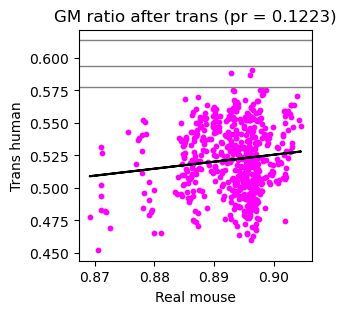

Pearson's r: 0.1433, p-value: 0.0007
R²: 0.0205


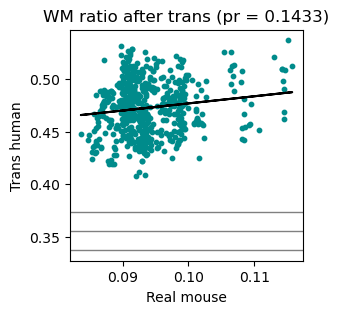

Pearson's r: 0.0381, p-value: 0.368
R²: 0.0015


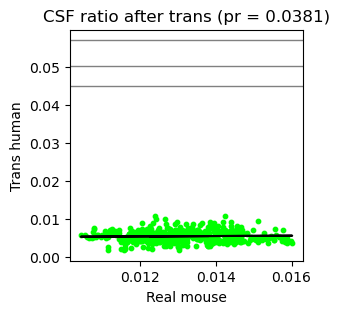

: 

In [ ]:
# RUNN
model = MLP.cuda() 
#model.load_state_dict(torch.load('./pca/gm_loss_mod_500.pth')['model_state_dict'])


mouse_ratios_means, mouse_ratios_stds = dataset.get_mouse_mean_and_std()
train_folder = "./datasets/3d_larger/mouse_train/"
test_folder = "./datasets/3d_larger/mouse_test/"

test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
test_paths.sort()

train_paths = [train_folder + file_name for file_name in os.listdir(train_folder)]
train_paths.sort()

def quick_analysis(paths):
    # 1 - get image arrs
    mouse_imgs = []
    for path in paths:
        mouse_img = sitk.ReadImage(path)
        mouse_img_arr = sitk.GetArrayFromImage(mouse_img)
        mouse_imgs.append(mouse_img_arr)

    # 2 - apply pca
    mouse_imgs = np.array(mouse_imgs)
    mouse_imgs_arr_flat = mouse_imgs.reshape(mouse_imgs.shape[0], mouse_imgs.shape[1]*mouse_imgs.shape[2]*mouse_imgs.shape[3]) # NOTE: update for 2D/3D
    mouse_imgs_arr_scaled = scaler_mouse.transform(mouse_imgs_arr_flat)
    mouse_pca_encodings = pca_mouse.transform(mouse_imgs_arr_scaled)

    # 3 - map to human encodings
    human_pca_encodings = model(torch.from_numpy(mouse_pca_encodings).cuda())

    # 4 - inverse pcas back to imgs
    human_trans = pca_human.inverse_transform(human_pca_encodings.detach().cpu())
    human_trans_unscale = scaler_human.inverse_transform(human_trans)
    human_imgs_trans = np.clip(np.round(human_trans_unscale.reshape(mouse_imgs.shape)), 0, 3)

    real_gm, real_wm, real_csf = compute_matter_ratios(mouse_imgs)
    trans_gm, trans_wm, trans_csf = compute_matter_ratios(human_imgs_trans)

    # plot
    analyze_matter_ratio_preservation(real_gm, trans_gm, "GM ratio after trans", "magenta", 0)
    analyze_matter_ratio_preservation(real_wm, trans_wm, "WM ratio after trans", "darkcyan", 1)
    analyze_matter_ratio_preservation(real_csf, trans_csf, "CSF ratio after trans", "lime", 2)

    # plot imgs variance
    img_stack = np.stack(human_imgs_trans, axis=0)
    voxel_variance = np.var(img_stack, axis=0)
    plt.figure(figsize=(3,3))
    plt.imshow(voxel_variance[slice_idx], "jet", vmin=0, vmax=2) # NOTE: diff in 2D and 3D
    plt.title("Trans human variance")
    plt.colorbar()
    plt.show()

    # plot the distributions to compare
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    bins = 100

    axs[0, 0].hist(real_human_gm, bins, edgecolor="darkorchid", color="mediumorchid")
    axs[0, 0].set_xlim(min(np.min(real_human_gm), np.min(trans_gm))*0.95, max(np.max(real_human_gm), np.max(trans_gm))*1.05)
    axs[0, 0].set_title('Real human gm')

    axs[1, 0].hist(trans_gm, bins, edgecolor="darkorchid", color="mediumorchid")
    axs[1, 0].set_xlim(min(np.min(real_human_gm), np.min(trans_gm))*0.95, max(np.max(real_human_gm), np.max(trans_gm))*1.05)
    axs[1, 0].set_title('Trans human wm')

    axs[0, 1].hist(real_human_wm, bins, edgecolor="darkslategrey", color="darkcyan")
    axs[0, 1].set_xlim(min(np.min(real_human_wm), np.min(trans_wm))*0.95, max(np.max(real_human_wm), np.max(trans_wm))*1.05)
    axs[0, 1].set_title('Real human csf')

    axs[1, 1].hist(trans_wm, bins, edgecolor="darkslategrey", color="darkcyan")
    axs[1, 1].set_xlim(min(np.min(real_human_wm), np.min(trans_wm))*0.95, max(np.max(real_human_wm), np.max(trans_wm))*1.05)
    axs[1, 1].set_title('Trans human gm')

    axs[0, 2].hist(real_human_csf, bins, edgecolor="seagreen", color="mediumseagreen")
    axs[0, 2].set_xlim(-0.01, max(np.max(real_human_csf), np.max(trans_csf))*1.05)
    axs[0, 2].set_title('Real human wm')

    axs[1, 2].hist(trans_csf, bins, edgecolor="seagreen", color="mediumseagreen")
    axs[1, 2].set_xlim(-0.01, max(np.max(real_human_csf), np.max(trans_csf))*1.05)
    axs[1, 2].set_title('Trans human csf')

    plt.tight_layout()
    plt.show()

    return human_trans_unscale


human_imgs = quick_analysis(test_paths)

0.5199553792761527


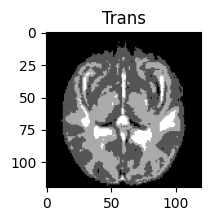

(diff) mouse gm: 0.8511 human_gm: 0.5695
(non diff) mouse gm: 0.8603 human_gm: 0.52
0.5757612667478684


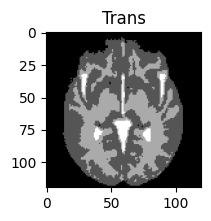

(diff) mouse gm: 0.8636 human_gm: 0.5934
(non diff) mouse gm: 0.8778 human_gm: 0.5758
0.5667345899133979


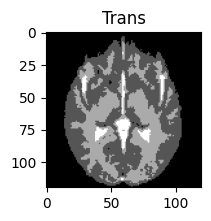

(diff) mouse gm: 0.8582 human_gm: 0.5949
(non diff) mouse gm: 0.8716 human_gm: 0.5667
0.5773666506487266


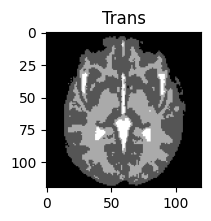

(diff) mouse gm: 0.8642 human_gm: 0.594
(non diff) mouse gm: 0.875 human_gm: 0.5774
0.5751580426129712


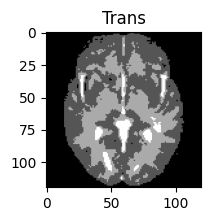

(diff) mouse gm: 0.8643 human_gm: 0.5914
(non diff) mouse gm: 0.8706 human_gm: 0.5752
0.4948721117014704


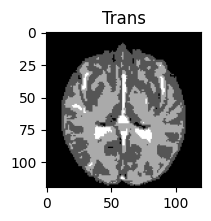

(diff) mouse gm: 0.8351 human_gm: 0.5342
(non diff) mouse gm: 0.8352 human_gm: 0.4949
0.6019923549171783


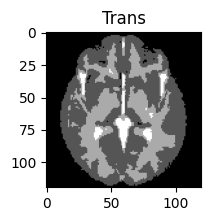

(diff) mouse gm: 0.8785 human_gm: 0.6119
(non diff) mouse gm: 0.8911 human_gm: 0.602
0.5740218324543113


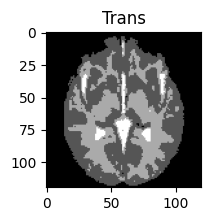

(diff) mouse gm: 0.8646 human_gm: 0.5969
(non diff) mouse gm: 0.877 human_gm: 0.574
0.5688160551003444


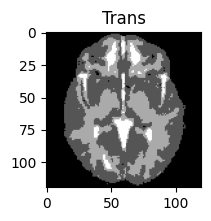

(diff) mouse gm: 0.8656 human_gm: 0.598
(non diff) mouse gm: 0.878 human_gm: 0.5688
0.5885364635364635


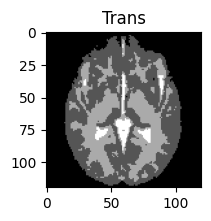

(diff) mouse gm: 0.8725 human_gm: 0.6095
(non diff) mouse gm: 0.8879 human_gm: 0.5885


In [ ]:
mouse_ratios_means, mouse_ratios_stds = dataset.get_mouse_mean_and_std()
folder = "./datasets/2d_larger/mouse_train/"
paths = [folder + file_name for file_name in os.listdir(folder)]
random.shuffle(np.array(paths))
slice_idx = 60

save_path = "./pca/trans_test/"

os.makedirs(save_path, exist_ok=True)

for path in paths[:10]:
    mouse_img = sitk.ReadImage(path)
    mouse_img_arr = sitk.GetArrayFromImage(mouse_img)
    mouse_img_arr_flat = mouse_img_arr.flatten().reshape(1, -1)
    mouse_img_arr_scaled = scaler_mouse.transform(mouse_img_arr_flat)
    mouse_pca_encoding = pca_mouse.transform(mouse_img_arr_scaled)

    # map
    human_pca_encoding = model(torch.from_numpy(mouse_pca_encoding).cuda())

    human_trans = pca_human.inverse_transform(human_pca_encoding.detach().cpu())
    human_trans_unscale = scaler_human.inverse_transform(human_trans)
    human_img_trans = np.clip(np.round(human_trans_unscale.reshape(mouse_img_arr.shape)), 0, 3)

    print(np.sum(human_img_trans == 1) / np.sum(human_img_trans != 0))

    plt.figure(figsize=(2,3))
    plt.imshow(human_img_trans, cmap='gray')
    plt.title("Trans")
    plt.show()

    gm_mouse = get_gm_diff(torch.from_numpy(mouse_img_arr)) 
    gm_human = get_gm_diff(torch.from_numpy(human_trans_unscale))

    gm_mouse_nd = get_gm_non_diff(torch.from_numpy(mouse_img_arr)) 
    gm_human_nd = get_gm_non_diff(torch.from_numpy(human_trans_unscale))

    mouse_gm_norm = (gm_mouse - mouse_ratios_means[0]) / (mouse_ratios_stds[0] + 1e-6)
    human_gm_norm = (gm_human - human_ratios_means[0]) / (human_ratios_stds[0] + 1e-6)

    print("(diff) mouse gm:", round(gm_mouse.item(), 4), "human_gm:", round(gm_human.item(), 4))
    print("(non diff) mouse gm:", round(gm_mouse_nd.item(), 4), "human_gm:", round(gm_human_nd.item(), 4))

    #trans_map_niffty = sitk.GetImageFromArray(human_img_trans)
    #sitk.WriteImage(trans_map_niffty, save_path + path.split("/")[-1])

# train takes ~7min

[0. 1. 2. 3.]


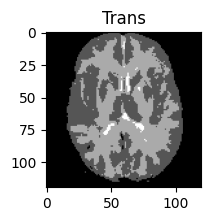

[0. 1. 2. 3.]


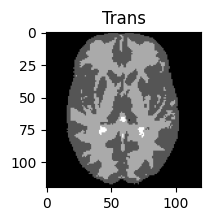

[0. 1. 2. 3.]


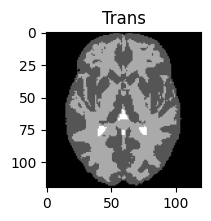

[0. 1. 2. 3.]


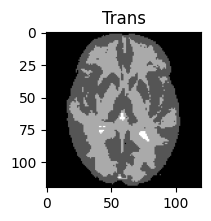

[0. 1. 2. 3.]


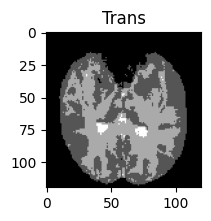

In [ ]:
idxs = [10, 20, 30, 40, 50]

for idx in idxs:
    recon = human_imgs_trans[idx]

    print(np.unique(recon))
    plt.figure(figsize=(2,3))
    plt.imshow(recon, cmap='gray')
    plt.title("Trans")
    plt.show()

In [ ]:

def save_recons(save_path, imgs, file_names):
    os.makedirs(save_path, exist_ok=True)
    for i, img in enumerate(imgs):
        sitk.WriteImage(sitk.GetImageFromArray(img), save_path + file_names[i])

save_path = "./pca/pca_100_MLP_mapping/pca_human_train_100_trans/"
save_recons(save_path, human_imgs_trans, mouse_train_file_names)

print(len(mouse_train_file_names))

2208


### Analyze distribution of latent encodings

Mean of means: 0.4012
Std of means: 0.9908
Mean of stds: 0.2303
Std of stds: 0.1327
Mean of norms: 19.5872
Std of norms: 16.9107


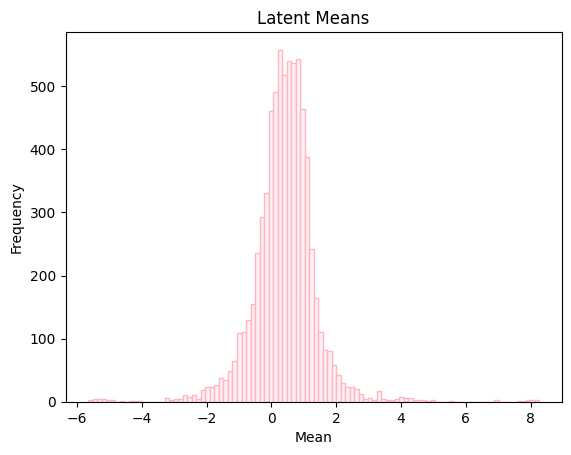

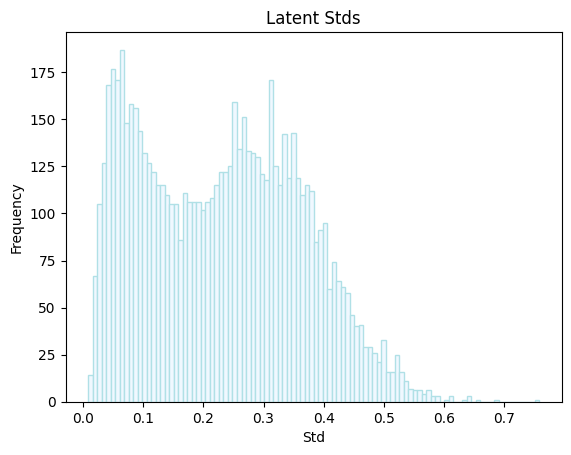

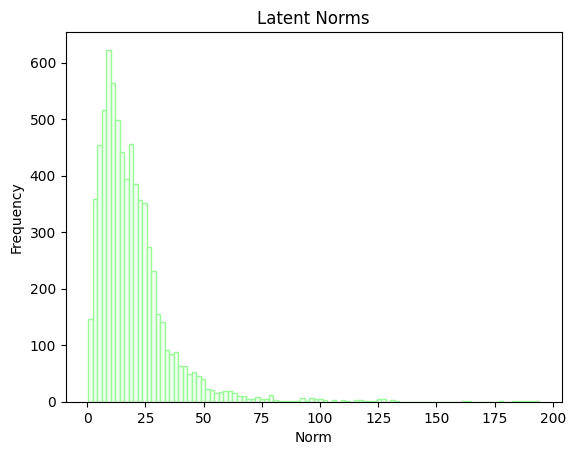

Mean of means: 0.3729
Std of means: 1.1128
Mean of stds: 0.2813
Std of stds: 0.1377
Mean of norms: 20.5682
Std of norms: 19.7813


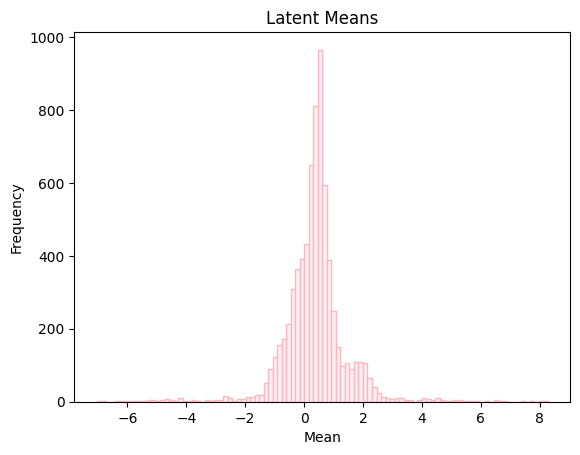

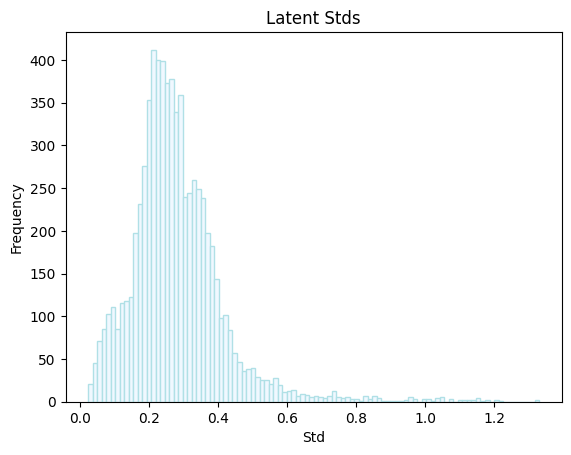

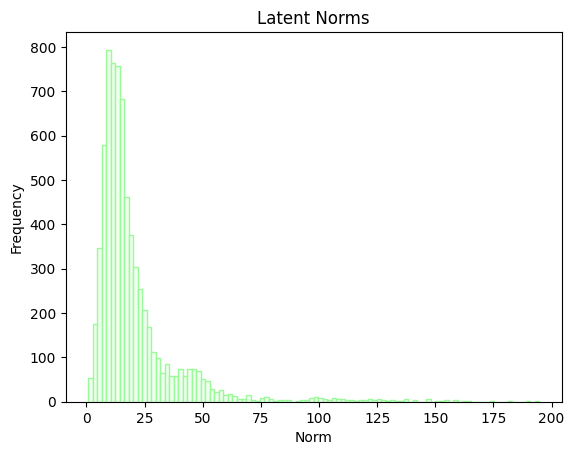

In [ ]:
# Dataset
mouse_encodings_folder = "./save_2d/2d_larger/mouse_train_1/train_latent_encodings/"
human_encodings_folder = "./save_2d/2d_larger/human_train_1/train_latent_encodings/"

mouse_test_encodings_folder = "./save_2d/2d_larger/mouse_train_1/test_latent_encodings/"
human_test_encodings_folder = "./save_2d/2d_larger/human_train_1/test_latent_encodings/"

dataset = LatentVectorDataset(mouse_test_encodings_folder, human_test_encodings_folder)
batch_size = dataset.__len__() # known num of train vectors
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

mouse_batch, human_batch = next(iter(dataloader))

def plot_latent_vect_dists(encodings):
    means = encodings.mean(dim=0)
    stds = encodings.std(dim=0)
    norms = encodings.norm(dim=0)

    print("Mean of means:", np.round(means.mean().numpy(), 4))
    print("Std of means:", np.round(means.std().numpy(), 4))

    print("Mean of stds:", np.round(stds.mean().numpy(), 4))
    print("Std of stds:", np.round(stds.std().numpy(), 4))

    print("Mean of norms:", np.round(norms.mean().numpy(), 4))
    print("Std of norms:", np.round(norms.std().numpy(), 4))

    plt.hist(means, bins=100, edgecolor="lightpink", color="lavenderblush")
    plt.xlabel("Mean")
    plt.ylabel("Frequency")
    plt.title("Latent Means")
    plt.show()

    plt.hist(stds, bins=100, edgecolor="powderblue", color="aliceblue")
    plt.xlabel("Std")
    plt.ylabel("Frequency")
    plt.title("Latent Stds")
    plt.show()

    plt.hist(norms, bins=100, edgecolor="palegreen", color="honeydew")
    plt.xlabel("Norm")
    plt.ylabel("Frequency")
    plt.title("Latent Norms")
    plt.show()

    return means, stds

mouse_means, mouse_stds = plot_latent_vect_dists(mouse_batch)
human_means, human_stds = plot_latent_vect_dists(human_batch)
